In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading real habit tracker data--
Loaded successfully! found 500 tracking entries
Now catagorising days with a mood rating 

 Running a operation to isolate the behavioral shifts
-----------------------------------------------------------------
      Mood_Category         Steps  Sleep_Hours  Study_Hours
0         Good Mood  10997.882353     7.307647     4.271765
1  Low/Netrual Mood  10423.215152     7.228788     3.923636
-----------------------------------------------------------------
 Comparing the stats and presenting into a graph
Scatter graph - Sleep Hour vs Steps Taken
Average steps taken as per mood


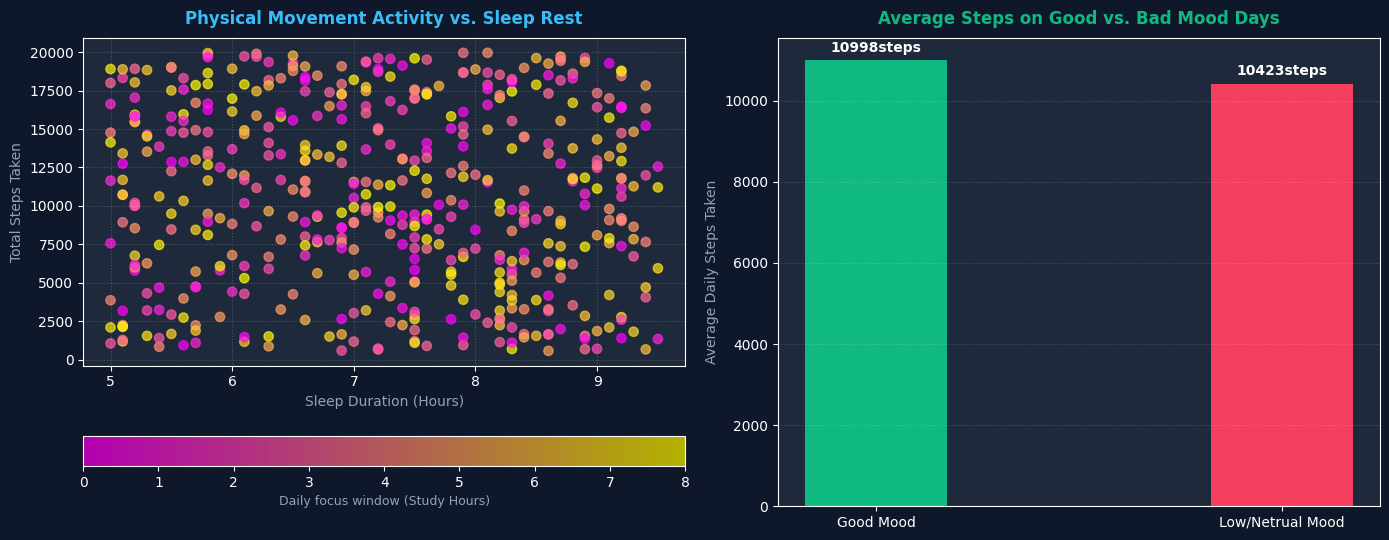

In [9]:
print("Loading real habit tracker data--")

try:
    df = pd.read_csv(r"C:\Users\soumik\Documents\Dataset\Daily_Habit_Tracker.csv")
    print(f"Loaded successfully! found {len(df)} tracking entries")

except FileNotFoundError:
    print("data/data2.csv not found so creating a quick local matching demo sample")
    np.random.seed(42)

    df = pd.DataFrame({
        'Sleep_Hours': np.random.uniform(5.0,9.5,100),
        'Steps': np.random.randint(2000,15000,100),
        'Study_Hours': np.random.randint(0,8,100),
        'Mood_Score': np.random.choice([4,5,6,7,8,9,10],100)
    })

print("Now catagorising days with a mood rating ") # it just rate the day as per the mood is >= 8 its good mood or
                                                    # accordingly moderate bad

df["Mood_Category"]=np.where(df["Mood_Score"]>=8,"Good Mood","Low/Netrual Mood")

print("\n Running a operation to isolate the behavioral shifts")
mood_summary=df.groupby("Mood_Category")[["Steps","Sleep_Hours","Study_Hours"]].mean().reset_index()
print("-" *65)
print(mood_summary)
print("-" *65)

print(" Comparing the stats and presenting into a graph")
plt.style.use("dark_background")
fig,axes=plt.subplots(1,2, figsize=(14,5.5))
fig.patch.set_facecolor("#0f172a")

print("Scatter graph - Sleep Hour vs Steps Taken")
ax1=axes[0]
ax1.set_facecolor("#1e293b")

scatter=ax1.scatter(df['Sleep_Hours'],df['Steps'],c=df['Study_Hours'],cmap='spring',alpha=0.7,s=45)
cbar=fig.colorbar(scatter,ax=ax1,orientation='horizontal',pad=0.15)
cbar.set_label('Daily focus window (Study Hours)',color='#94a3b8',fontsize=9)

ax1.set_title('Physical Movement Activity vs. Sleep Rest',fontsize=12,fontweight='bold',color='#38bdf8',pad=10)
ax1.set_xlabel('Sleep Duration (Hours)',color='#94a3b8')
ax1.set_ylabel('Total Steps Taken',color='#94a3b8')
ax1.grid(True,linestyle=':',alpha=0.2)

print("Average steps taken as per mood")
ax2=axes[1]
ax2.set_facecolor("#1e293b")

categories=mood_summary['Mood_Category']
step_averages=mood_summary['Steps']

#painting the 'Good Mood' group bar bright green
bar_colors=['#10b981' if cat=="Good Mood" else '#f43f5e' for cat in catagories] # a color condition is made
ax2.bar(categories,step_averages,color=bar_colors,width=0.35,edgecolor="none") # that color condition is passed into this

ax2.set_title('Average Steps on Good vs. Bad Mood Days',fontsize=12,fontweight='bold',color='#10b981',pad=10)
ax2.set_ylabel('Average Daily Steps Taken',color='#94a3b8')
ax2.grid(axis='y',linestyle=':',alpha=0.2)

for idx,num in enumerate(step_averages):
    ax2.text(idx,num+200,f"{num:.0f}steps",ha='center',color='white',fontweight='bold',fontsize=10)

plt.tight_layout()
plt.show()